/var/folders/4r/jhc99db14v58mjmncgtry0kc0000gn/T/ipykernel_63120/1742802673.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/4r/jhc99db14v58mjmncgtry0kc0000gn/T/ipykernel_63120/1742802673.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



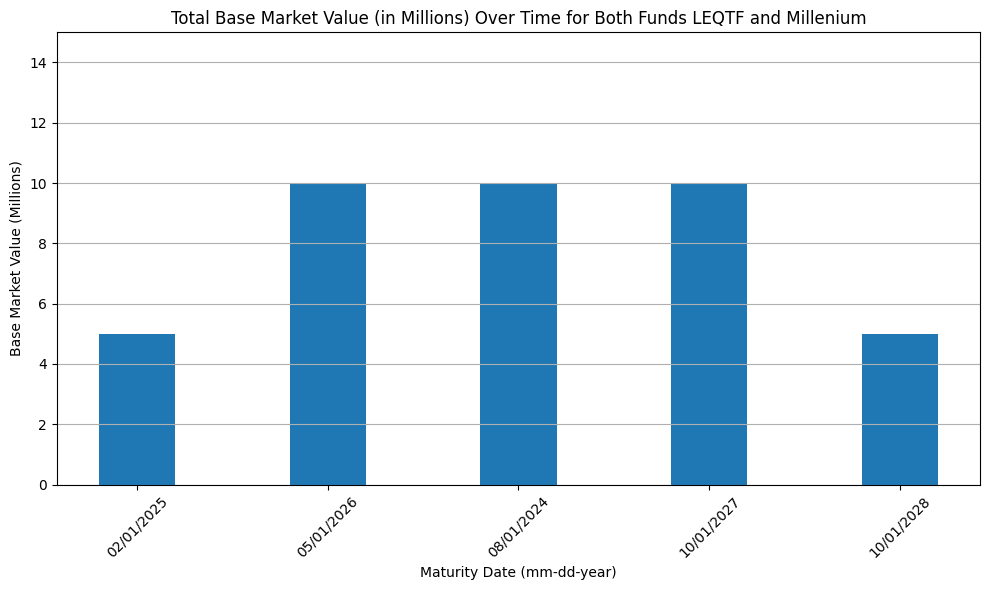

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv("../data/input/maturity/table1.csv")

# Filter the data for rows where Security Description1 is LEQTF and the other security description
df_leqtf = df[df['Security Description1'] == 'LEQTF FIXED INCOME']
df_other = df[df['Security Description1'] != 'LEQTF FIXED INCOME']

# Sum the Base Market Value for both groups
df_leqtf['Base Market Value'] = pd.to_numeric(df_leqtf['Base Market Value'].str.replace(',', ''), errors='coerce') / 1e6
df_other['Base Market Value'] = pd.to_numeric(df_other['Base Market Value'].str.replace(',', ''), errors='coerce') / 1e6

# Concatenate the sums by grouping by Maturity Date
df_combined = pd.concat([df_leqtf, df_other]).groupby('Maturity Date')['Base Market Value'].sum().reset_index()

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(df_combined['Maturity Date'], df_combined['Base Market Value'], width=0.4)

# Formatting the plot
plt.title('Total Base Market Value (in Millions) Over Time for Both Funds LEQTF and Millenium')
plt.xlabel('Maturity Date (mm-dd-year)')
plt.ylabel('Base Market Value (Millions)')
plt.xticks(rotation=45)
plt.ylim(0, 15)  # Set the y-axis limit to 15
plt.grid(True, axis='y')

# Show the plot
plt.tight_layout()
plt.show()
